# TASK-5  Sale Prediction using Python

### Load The data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv("Advertising Budget and sales.csv")

# Show the first 5 rows
df.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [2]:
# Renaming the column for easy execution
df = df.rename(columns={
    "TV Ad Budget ($)": "TV",
    "Radio Ad Budget ($)": "Radio",
    "Newspaper Ad Budget ($)": "Newspaper",
    "Sales ($)": "Sales"
})

# Drop the extra index column if it exists
if "Unnamed: 0" in df.columns:
    df = df.drop("Unnamed: 0", axis=1)

# Check that it worked
print(df.columns.tolist())
df.head()

['TV', 'Radio', 'Newspaper', 'Sales']


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [3]:
# Drop the useless index column (only if it exists)
if "Unnamed: 0" in df.columns:
    df = df.drop("Unnamed: 0", axis=1)

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


### Exploratory Data Analysis (EDA)

In [4]:
# 1. Size of the data (rows, columns)
print("Shape:", df.shape)

# 2. Check for null (missing) values
print(df.isnull().sum())

# 3. Descriptive statistics
df.describe()


Shape: (200, 4)
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


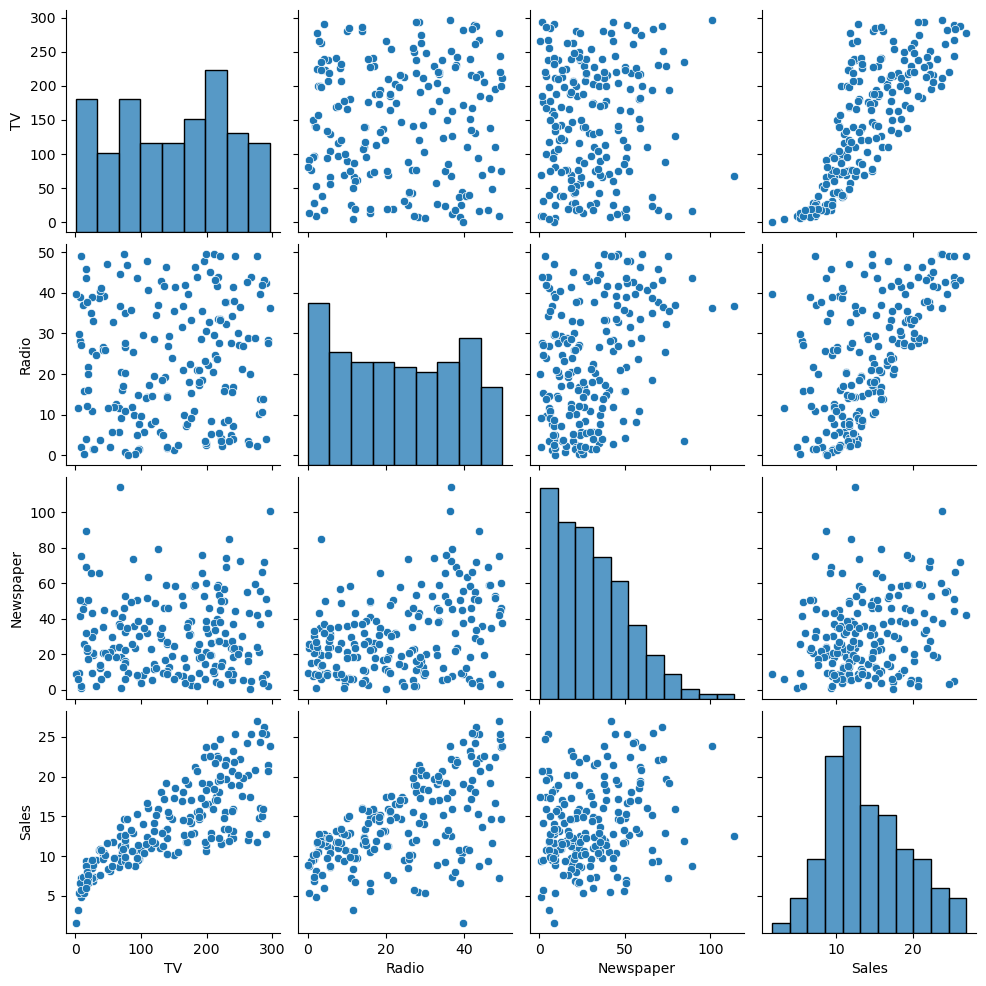

In [5]:
# 4.Pairplot
sns.pairplot(df)
plt.show()

### Individual Scatter Plots

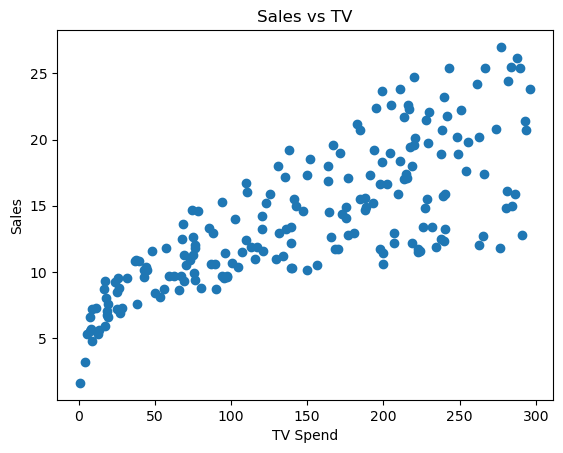

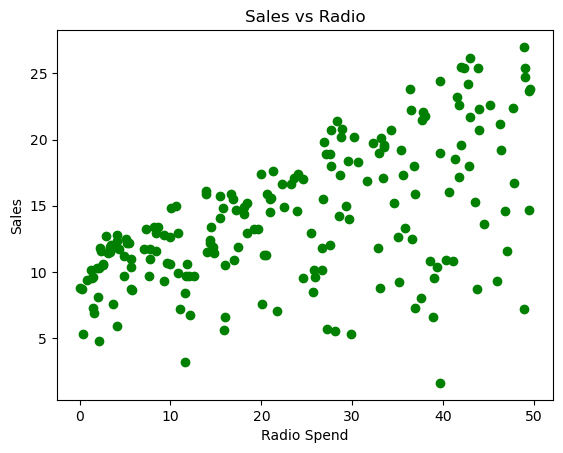

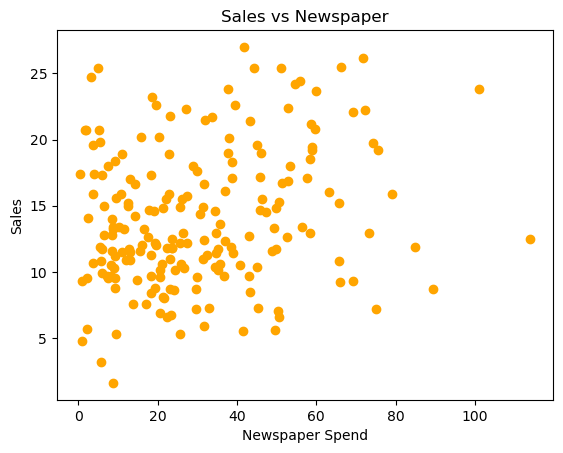

In [6]:
# Sales vs TV
plt.scatter(df["TV"], df["Sales"])
plt.xlabel("TV Spend")
plt.ylabel("Sales")
plt.title("Sales vs TV")
plt.show()

# Sales vs Radio
plt.scatter(df["Radio"], df["Sales"], color="green")
plt.xlabel("Radio Spend")
plt.ylabel("Sales")
plt.title("Sales vs Radio")
plt.show()

# Sales vs Newspaper
plt.scatter(df["Newspaper"], df["Sales"], color="orange")
plt.xlabel("Newspaper Spend")
plt.ylabel("Sales")
plt.title("Sales vs Newspaper")
plt.show()

### Correlation Heatmap

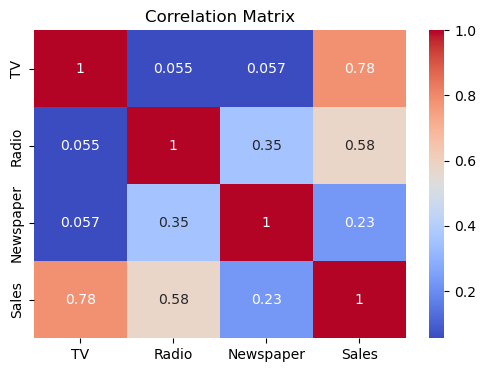

In [7]:
# Calculate correlation between all columns
corr = df.corr()

# Draw heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Train/Test Split

In [8]:
# X = inputs, y = what we want to predict
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 160
Testing rows: 40


### Train a Linear Regression as baseline

In [10]:
# Create the model
lr = LinearRegression()

# Train it (fit = learn from data)
lr.fit(X_train, y_train)

# Predict on the test data
lr_pred = lr.predict(X_test)

### Addtional Model (Random Forest)

In [11]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

### Evaluation 

In [12]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(name)
    print("  MAE :", round(mae, 3))
    print("  RMSE:", round(rmse, 3))
    print("  R2  :", round(r2, 3))
    print()

evaluate("Linear Regression", y_test, lr_pred)
evaluate("Random Forest", y_test, rf_pred)

Linear Regression
  MAE : 1.461
  RMSE: 1.782
  R2  : 0.899

Random Forest
  MAE : 0.62
  RMSE: 0.769
  R2  : 0.981



### Residual Plot

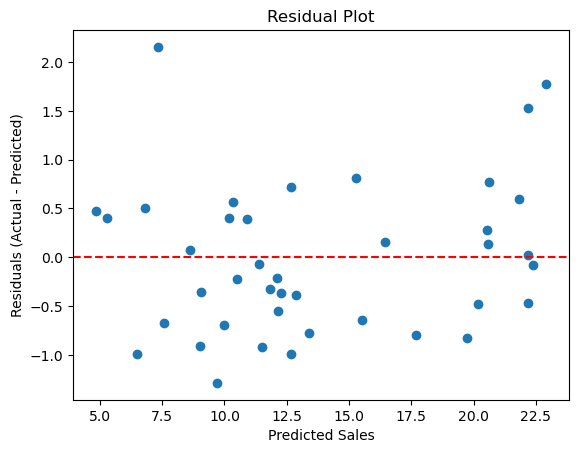

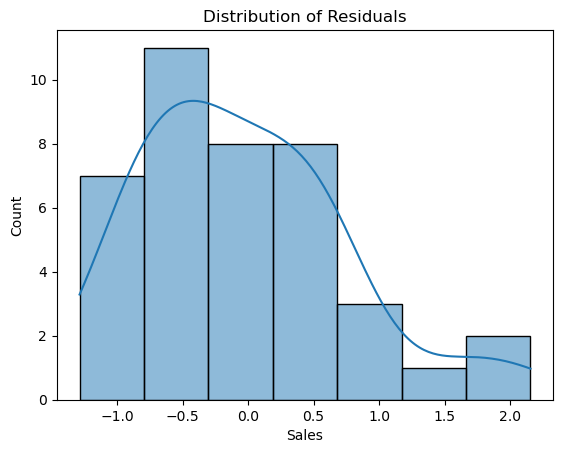

In [13]:
# Pick the best model (change this if Linear Regression wins in your run)
best_pred = rf_pred

# Calculate residuals
residuals = y_test - best_pred

# Residual plot
plt.scatter(best_pred, residuals)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

# Bonus: distribution of the errors
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.show()

### Interpretation

In [14]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})
print(coef_df)
print("Intercept:", lr.intercept_)

     Feature  Coefficient
0         TV     0.044730
1      Radio     0.189195
2  Newspaper     0.002761
Intercept: 2.9790673381226274


     Feature  Importance
0         TV    0.624810
1      Radio    0.362201
2  Newspaper    0.012989


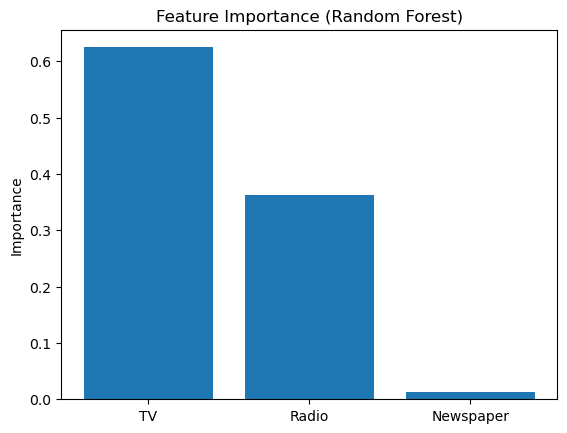

In [15]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance)

plt.bar(importance["Feature"], importance["Importance"])
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.show()